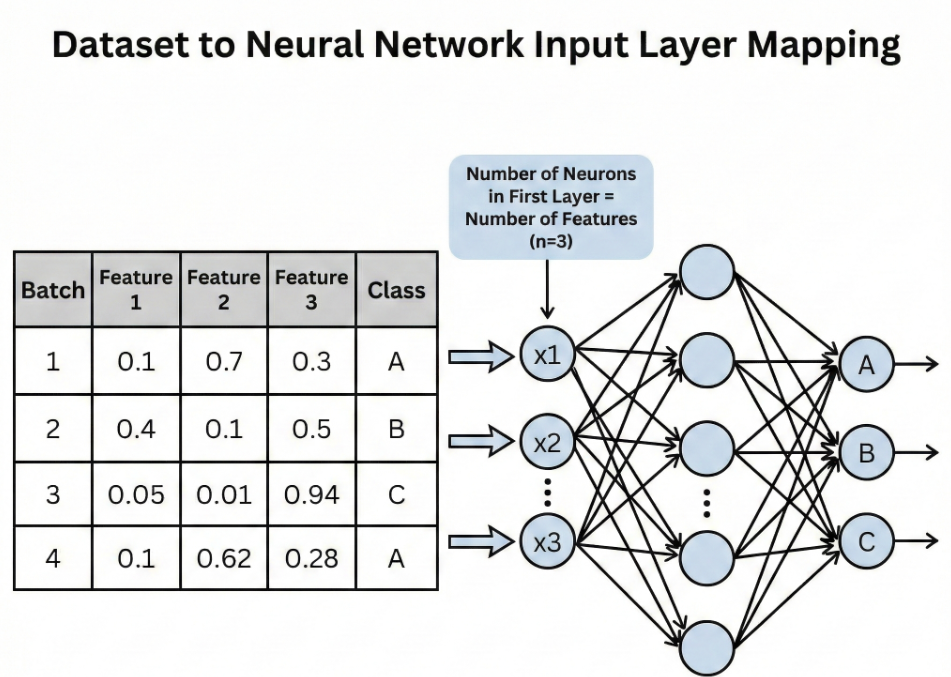

In [4]:
import numpy as np

In [5]:
class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)
        return self.output

In [6]:
class Activation_Softmax:

    def forward(self, inputs):
        self.input = inputs
        exp_vals = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        prob = exp_vals/np.sum(exp_vals, axis=1, keepdims=True)
        self.output = prob
        #return prob

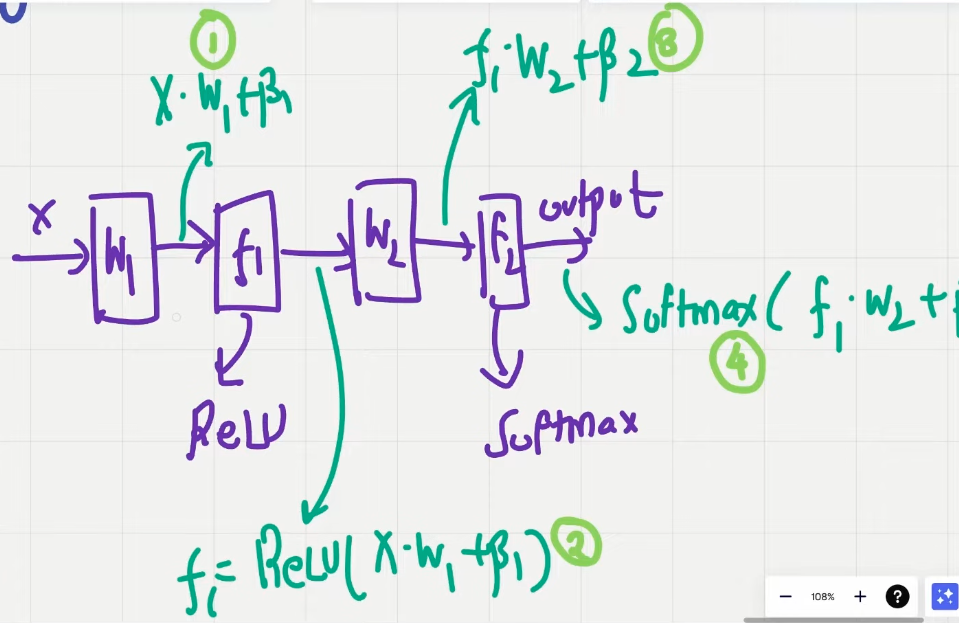

In [ ]:
import numpy as np
import nnfs 
from nnfs.datasets import spiral_data
nnfs.init()

#Dense layer
class Layer_Dense:
    #layer init
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons) #not n_neurons x n_inputs --> 
        self.biases = np.zeros((1, n_neurons))                     #to avoid the transpose in dot products

    #forward pass
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output                                        

#Create dataset
#X, y = spiral_data(samples=100, classes=3)
X, y = np.random.randn(300000, 1000), np.random.randint(low=0, high=2, size=(300, ))
print("y:",y[:5])
print(f"X, Y shape:{X.shape}, {y.shape}")


dense1 = Layer_Dense(1000, 10)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(10, 3)
activation2  = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])

print("X shape:", X.shape)
print("dense2 weights shape:", dense2.weights.shape)
print("final output shape:", activation2.output.shape)

y: [0 1 0 0 1]
X, Y shape:(300000, 1000), (300,)


In [1]:
#pip install cupy-cuda13x 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 2.2 MB/s  0:00:30 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [cupy-cuda13x]0m 1/2 [cupy-cuda13x]
Note: you may need to restart the kernel to use updated packages.


In [26]:
import cupy as np
import time
import nnfs 
from nnfs.datasets import spiral_data
nnfs.init()

t1 = time.time()

#Dense layer
class Layer_Dense:
    #layer init
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons) #not n_neurons x n_inputs --> 
        self.biases = np.zeros((1, n_neurons))                     #to avoid the transpose in dot products

    #forward pass
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output                                        

#Create dataset
#X, y = spiral_data(samples=100, classes=3)
X, y = np.random.randn(10000, 8000), np.random.randint(low=0, high=2, size=(10000, ))
print("y:",y[:5])
print(f"X, Y shape:{X.shape}, {y.shape}")


dense1 = Layer_Dense(8000, 10)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(10, 3)
activation2  = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

t_aken = time.time() - t1

print("Time taken -->", t_aken)

print(activation2.output[:5])

print("X shape:", X.shape)
print("dense2 weights shape:", dense2.weights.shape)
print("final output shape:", activation2.output.shape)

y: [1 0 1 1 0]
X, Y shape:(10000, 8000), (10000,)
Time taken --> 0.06435632705688477
[[0.32232656 0.35238242 0.32529102]
 [0.32935825 0.3382062  0.33243555]
 [0.33687546 0.34433358 0.31879096]
 [0.32327944 0.34075499 0.33596557]
 [0.33156457 0.33969074 0.3287447 ]]
X shape: (10000, 8000)
dense2 weights shape: (10, 3)
final output shape: (10000, 3)
